In [1]:
from moabb.paradigms import P300
from moabb.datasets import *


paradigm = P300(resample=48)
dataset = BNCI2014008()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
     subjects=[1],
     return_epochs=True
)
session = meta['session'][1]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]

BNCI2014008 has been renamed to BNCI2014_008. BNCI2014008 will be removed in version 1.1.
The dataset class name 'BNCI2014008' must be an abbreviation of its code 'BNCI2014-008'. See moabb.datasets.base.is_abbrev for more information.
/usr/local/lib/python3.11/site-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 4200 events (all good), 0 – 1 s (baseline off), ~65.9 MB, data loaded,
 'Target': 700
 'NonTarget': 3500>
  warn(f"warnEpochs {epochs}")


Adding metadata with 3 columns
Adding metadata with 3 columns
4200 matching events found
No baseline correction applied


/usr/local/lib/python3.11/site-packages/moabb/paradigms/base.py:350: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [54]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

X = tl.tensor(epochs.get_data())
y = np.array(labels)

In [55]:
hoda_params = dict(
        rank=None,
        max_iter=64,
        tol=1e-8,
        init ='random',
        shrinkage='lw',
        toeplitz=None,
        obj='tr',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=True,
        random_state=42,
        delta=None,       
    )

In [56]:
from sklearn.model_selection import StratifiedKFold
from hoda.hoda import BTTDA, GreedyBTTDA, HODA, trunc_eigh
from hoda.cov import mode_scatter
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import  warnings
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler
import warnings
from joblib import parallel_backend
from joblib import Parallel
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectFwe
from hoda.classification import SelectF

cv= StratifiedKFold(random_state=42,shuffle=True, n_splits=5)

clf = make_pipeline(
    #SelectF(alpha=0.05),
    FunctionTransformer(tl.to_numpy),
    StandardScaler(),
    LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
)

In [57]:
from hoda.hoda import GreedyBTTDA
import matplotlib.pyplot as plt
import math

df = []
for r in range(10):
    bttda = GreedyBTTDA(
        max_blocks=4,
        hoda_params=hoda_params,
        verbose=True,
        extra_train_info=False,
        rank_grid=[r+1],
        clf=clf,
        cv=cv,
    )
    bttda.fit(X,y)
    print(bttda.model_select_info_)


Model selection block 1/4...

Trying rank 1	

ValueError: dtype='numeric' is not compatible with arrays of bytes/strings.Convert your data to numeric values explicitly instead.

In [30]:
import numpy as np

F = np.array(F)
n_features = np.array(n_features)

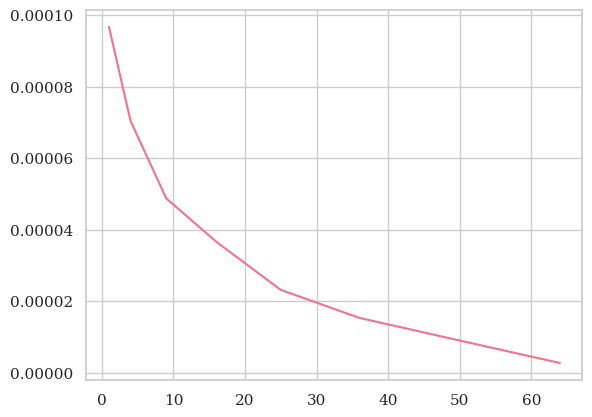

In [44]:
plt.plot(n_features, F)

In [10]:
import pandas as pd
pd.DataFrame(bttda.train_info_)


,block,rank,F_tr,F_rt,log_loss,mse,nmse
0,1,"(2, 2)",0.000070,0.000184,0.353007,1.065801e-10,0.998189
1,2,"(2, 2)",0.000071,0.000185,0.352475,1.064527e-10,0.996995
2,3,"(2, 2)",0.000057,0.000229,0.334176,1.062559e-10,0.995153
3,4,"(2, 2)",0.000046,0.000244,0.327825,1.061220e-10,0.993899
4,5,"(2, 2)",0.000042,0.000251,0.325116,1.059886e-10,0.992649
5,6,"(2, 2)",0.000031,0.000265,0.320646,1.052589e-10,0.985815
6,7,"(2, 2)",0.000030,0.000296,0.309302,1.050951e-10,0.984281
7,8,"(2, 2)",0.000029,0.000297,0.308891,1.048646e-10,0.982122
8,9,"(2, 2)",0.000029,0.000299,0.308051,1.048017e-10,0.981533
9,10,"(2, 2)",0.000028,0.000300,0.307707,1.047730e-10,0.981265
